Dataset Shape: (150, 6)

First 5 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1)

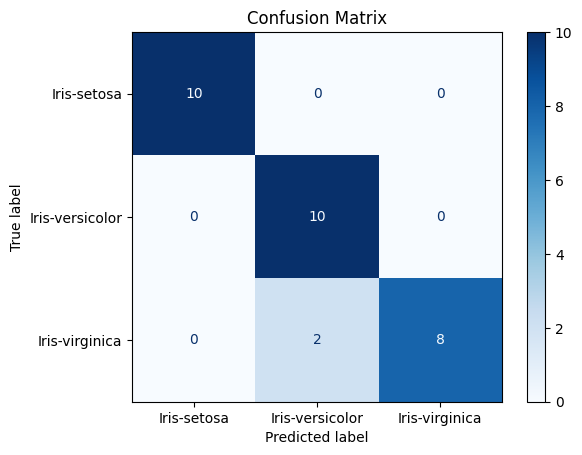

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("Iris.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nClass Distribution:")
print(df["Species"].value_counts())

# ==========================================
# Feature Selection
# ==========================================

X = df.drop(["Id", "Species"], axis=1)

y = df["Species"]

# Encode target labels
encoder = LabelEncoder()

y = encoder.fit_transform(y)

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# Experiment with Different K Values
# ==========================================

print("\nAccuracy for Different K Values")

k_values = [1, 3, 5, 7, 9]

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print(f"K = {k} --> Accuracy = {acc:.4f}")

# ==========================================
# Final Model
# ==========================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# ==========================================
# Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\nFinal Accuracy:", accuracy)

# ==========================================
# Classification Report
# ==========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

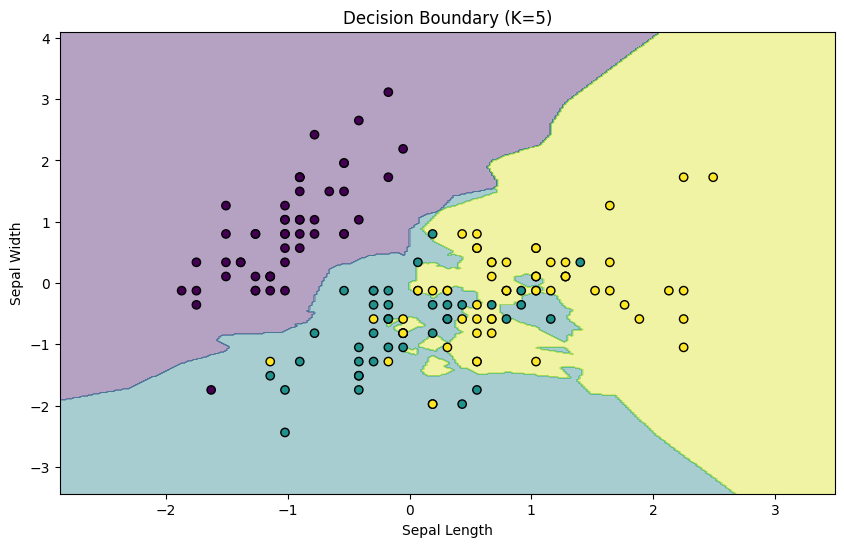

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("Iris.csv")

X = df[["SepalLengthCm", "SepalWidthCm"]]

y = df["Species"]

encoder = LabelEncoder()

y = encoder.fit_transform(y)

scaler = StandardScaler()

X = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X, y)

h = 0.02

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.4)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='k'
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

plt.title("Decision Boundary (K=5)")

plt.savefig("decision_boundary.png")

plt.show()